In [4]:
import pandas as pd
df_tx = pd.read_csv('./data/transcriptomics.csv', index_col=0)

df_tx = df_tx.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df_px = pd.read_csv('./data/proteomics.csv', index_col=0)

df_px = df_px.pivot_table(
    index='observableId',
    columns='preequilibrationConditionId',
    values='measurement'
)

df = pd.read_csv('./data/cytof.csv', index_col=0)

df_p = df[df['simulationConditionId'].str.split('__').str[1]=='EGF'].pivot_table(
    index='preequilibrationConditionId', columns='FEATURE_ID', values='measurement'
)

df_tx.index = [f't{m}' for m in df_tx.index]
df_px.index = [f'p{m}' for m in df_px.index]

df = pd.concat([df_p, df_tx.T, df_px.T], axis=1)

In [33]:
import numpy as np
def nancorr(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

corrs ={
    m : {
    col: nancorr(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [34]:
corrs = pd.DataFrame(corrs)
corrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.257196,0.109019,0.312650
GAPDH,0.128621,0.183306,0.142763
IdU,0.268101,0.121765,0.223139
Ki.67,0.172188,0.018894,0.174319
b.CATENIN,-0.054686,0.011227,0.023144
...,...,...,...
pZWINT,0.318603,0.176271,0.306542
pZYG11B,-0.067734,-0.085957,0.075806
pZYX,0.423460,0.463635,0.353236
pZZEF1,-0.162998,-0.088790,-0.335486


In [39]:
corrs.sort_values('p.p90RSK', ascending=True)

,p.p90RSK,p.ERK,p.p38
pRHOT2,-0.642628,-0.437499,-0.625449
tRNF41,-0.631521,-0.563600,-0.521199
tCCDC78,-0.614209,-0.580141,-0.607062
tFAHD1,-0.604768,-0.391325,-0.561114
tKIAA1257,-0.584236,-0.529737,-0.658800
...,...,...,...
pZNF652,NaN,NaN,NaN
pZNF664,NaN,NaN,NaN
pZNF703,NaN,NaN,NaN
pZNRF1,NaN,NaN,NaN


In [17]:
df[corrs.index[:20]]

,p.ERK,p.p38,p.S6K,p.MKK4,pRAB12,tTSPAN2,p.PLCg2,pNSFL1C,pLCN2,p.MKK3.MKK6,tHLA.DMB,pVCL,pKIFC1,tTIMP2,pGCLM,tPXDC1,p.JNK,pPLS1,tCDC14B,pPLS3
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,3.262251,2.292671,2.198164,3.853531,0.031677,-2.759,2.075076,-0.272787,-2.134359,2.318214,-2.899,-0.780859,-2.554616,5.859,-0.945404,3.206,1.864154,-0.399908,2.989,-0.087864
c184B5,3.043229,2.546793,2.123429,4.050533,-0.535497,-1.925,2.435268,-0.638384,-0.461162,2.506114,-2.848,-0.704277,-2.107189,4.930,-1.101790,5.216,1.813406,-0.089286,2.553,0.252593
cBT20,4.109490,3.088779,2.455114,4.811852,0.634803,2.419,3.352392,0.731129,0.624409,1.876707,-0.548,0.388070,0.291450,4.888,1.475848,3.612,1.791538,1.819727,3.092,1.718246
cBT474,3.157603,1.953173,2.081220,3.632600,-1.242475,-3.322,2.017268,-0.801771,-5.580786,1.557383,-2.697,-1.652083,-0.512752,1.321,-2.782634,-0.655,2.064395,-2.146904,1.174,-4.072195
cBT483,3.233732,2.452048,2.174411,3.357557,-0.196690,-3.322,2.026587,0.246395,-0.765271,1.392408,1.149,-0.541099,-0.203631,4.210,0.212407,0.928,1.318932,-0.147167,1.248,0.486221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,-0.442462,-0.851,NaN,-0.669613,NaN,NaN,-2.031,0.186917,-0.809215,5.496,-1.035243,3.114,NaN,-0.706649,4.120,0.466003
cZR75B,NaN,NaN,NaN,NaN,0.089741,-3.322,NaN,-0.401907,NaN,NaN,-3.322,0.448737,-1.376211,3.896,-0.989618,-0.693,NaN,-1.032778,1.840,-1.003895
cHCC2157,NaN,NaN,NaN,NaN,0.555978,NaN,NaN,0.268991,NaN,NaN,NaN,1.372482,0.528256,NaN,0.285530,NaN,NaN,0.639623,NaN,1.229480


In [19]:
df[corrs.index[:20]]

,p.ERK,p.p38,p.S6K,p.MKK4,pRAB12,tTSPAN2,p.PLCg2,pNSFL1C,pLCN2,p.MKK3.MKK6,tHLA.DMB,pVCL,pKIFC1,tTIMP2,pGCLM,tPXDC1,p.JNK,pPLS1,tCDC14B,pPLS3
preequilibrationConditionId,,,,,,,,,,,,,,,,,,,,
c184A1,3.262251,2.292671,2.198164,3.853531,0.031677,-2.759,2.075076,-0.272787,-2.134359,2.318214,-2.899,-0.780859,-2.554616,5.859,-0.945404,3.206,1.864154,-0.399908,2.989,-0.087864
c184B5,3.043229,2.546793,2.123429,4.050533,-0.535497,-1.925,2.435268,-0.638384,-0.461162,2.506114,-2.848,-0.704277,-2.107189,4.930,-1.101790,5.216,1.813406,-0.089286,2.553,0.252593
cBT20,4.109490,3.088779,2.455114,4.811852,0.634803,2.419,3.352392,0.731129,0.624409,1.876707,-0.548,0.388070,0.291450,4.888,1.475848,3.612,1.791538,1.819727,3.092,1.718246
cBT474,3.157603,1.953173,2.081220,3.632600,-1.242475,-3.322,2.017268,-0.801771,-5.580786,1.557383,-2.697,-1.652083,-0.512752,1.321,-2.782634,-0.655,2.064395,-2.146904,1.174,-4.072195
cBT483,3.233732,2.452048,2.174411,3.357557,-0.196690,-3.322,2.026587,0.246395,-0.765271,1.392408,1.149,-0.541099,-0.203631,4.210,0.212407,0.928,1.318932,-0.147167,1.248,0.486221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cMDAMB436,NaN,NaN,NaN,NaN,-0.442462,-0.851,NaN,-0.669613,NaN,NaN,-2.031,0.186917,-0.809215,5.496,-1.035243,3.114,NaN,-0.706649,4.120,0.466003
cZR75B,NaN,NaN,NaN,NaN,0.089741,-3.322,NaN,-0.401907,NaN,NaN,-3.322,0.448737,-1.376211,3.896,-0.989618,-0.693,NaN,-1.032778,1.840,-1.003895
cHCC2157,NaN,NaN,NaN,NaN,0.555978,NaN,NaN,0.268991,NaN,NaN,NaN,1.372482,0.528256,NaN,0.285530,NaN,NaN,0.639623,NaN,1.229480


In [21]:
corrs

p.ERK      0.732872
p.p38      0.714423
p.S6K      0.705492
p.MKK4     0.672609
pRAB12     0.611858
             ...   
pZNF618         NaN
pZNF652         NaN
pZNF664         NaN
pZNF703         NaN
pZNRF1          NaN
Length: 24475, dtype: float64

In [26]:
from scipy import stats
def nancorr_p(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 30:
        return np.nan
    return stats.pearsonr(a[mask], b[mask])[1]

In [27]:
nancorr_p(df['p.p90RSK'], df['pRAB12'])

np.float64(1.4406427571678838e-06)

In [41]:
df_p.columns

Index(['CyclinB', 'GAPDH', 'IdU', 'Ki.67', 'b.CATENIN', 'cleavedCas',
       'p.4EBP1', 'p.AKT.Thr308.', 'p.AMPK', 'p.Akt.Ser473.', 'p.BTK',
       'p.CREB', 'p.ERK', 'p.FAK', 'p.GSK3b', 'p.H3', 'p.HER2', 'p.JNK',
       'p.MAP2K3', 'p.MAPKAPK2', 'p.MEK', 'p.MKK3.MKK6', 'p.MKK4', 'p.NFkB',
       'p.PDPK1', 'p.PLCg2', 'p.RB', 'p.S6', 'p.S6K', 'p.SMAD23', 'p.SRC',
       'p.STAT1', 'p.STAT3', 'p.STAT5', 'p.p38', 'p.p53', 'p.p90RSK'],
      dtype='object', name='FEATURE_ID')

In [44]:
pcorrs ={
    m : {
    col: nancorr_p(df[m], df[col])
    for col in df.columns if col != m
    } for m in ('p.p90RSK', 'p.ERK', 'p.p38')
}

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_68857/196763736.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return stats.pearsonr(a[mask], b[mask])[1]


In [45]:
pcorrs = pd.DataFrame(pcorrs)
pcorrs

,p.p90RSK,p.ERK,p.p38
CyclinB,0.065668,4.416963e-01,2.403014e-02
GAPDH,0.363489,1.933417e-01,3.126687e-01
IdU,0.054650,3.898332e-01,1.118156e-01
Ki.67,0.222229,8.942333e-01,2.164728e-01
b.CATENIN,0.700203,9.370382e-01,8.706284e-01
...,...,...,...
pZWINT,0.025672,2.256809e-01,3.217192e-02
pZYG11B,0.643775,5.570324e-01,6.046739e-01
pZYX,0.001760,5.369066e-04,1.020834e-02
pZZEF1,0.248268,5.313490e-01,1.504333e-02


<Axes: >

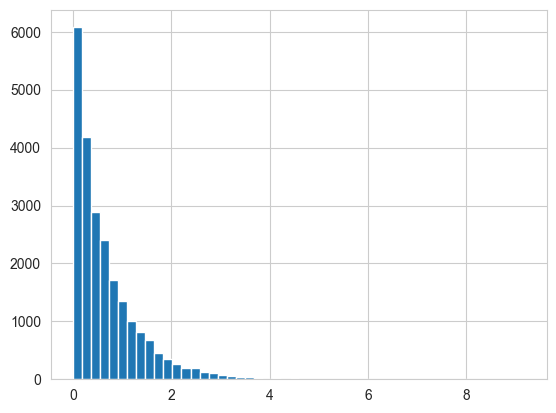

In [54]:
from scipy.stats import false_discovery_control
pcorrs['p.p90RSK'].apply(lambda p: -np.log10(p)).hist(bins=50)

In [75]:
df_fin = pcorrs['p.p90RSK'].loc[np.isfinite(pcorrs['p.p90RSK'].values)]
pval = pd.Series(false_discovery_control(df_fin), index=df_fin.index)
pval[pval < 0.05].sort_values()

p.ERK       0.000015
p.p38       0.000031
p.S6K       0.000040
p.MKK4      0.000273
pRHOT2      0.001296
              ...   
pMRPL57     0.048519
tTMEM63C    0.048577
tCNN3       0.048577
pMRPL16     0.048577
tCHST8      0.049889
Length: 110, dtype: float64

In [59]:
pcorrs['p.p90RSK'].max(
)

np.float64(0.999963186229898)

In [76]:
!pip install gseapy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [121]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl = [g[1:] for g in pval[pval < 0.05].index if g.startswith('t')]
bg = [g[1:] for g in pval.index if g.startswith('t')]
enr_tx = gp.enrichr(
    gene_list=gl,
    gene_sets=sets,
    organism='human',
    background=bg,
    outdir=None,
)
enr_tx.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
655,MSigDB_Hallmark_2020,KRAS Signaling Up,0.000047,0.000936,0,0,10.444873,104.131137,PIGR;GPRC5B;LIF;ETS1;ETV4;CTSS
556,GO_Molecular_Function_2025,Metalloendopeptidase Inhibitor Activity (GO:00...,0.000011,0.001082,0,0,91.222222,1042.097305,RARRES1;TIMP2;RECK
656,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,0.000485,0.004850,0,0,8.489758,64.788310,GLIPR2;LIF;MAP3K8;ETV4;TGM2
474,GO_Cellular_Component_2025,Tertiary Granule Lumen (GO:1904724),0.000607,0.049760,0,0,20.228395,149.837236,TIMP2;QSOX1;CTSS
475,GO_Cellular_Component_2025,Tertiary Granule (GO:0070820),0.001540,0.052854,0,0,8.781671,56.871194,RCAN1;TIMP2;QSOX1;CTSS
...,...,...,...,...,...,...,...,...,...
1271,Reactome_Pathways_2024,RNA Polymerase II Transcription,0.937648,0.958394,0,0,0.440836,0.028381,ZSCAN32;TRIAP1
1272,Reactome_Pathways_2024,Cellular Responses to Stimuli,0.941580,0.958394,0,0,0.349343,0.021029,ETS1
1273,Reactome_Pathways_2024,Gene Expression (Transcription),0.967601,0.979000,0,0,0.372013,0.012252,ZSCAN32;TRIAP1
1274,Reactome_Pathways_2024,Metabolism,0.973275,0.979000,0,0,0.408254,0.011059,CERS6;FAHD1;SMOX


In [122]:
import gseapy as gp
sets = ['GO_Biological_Process_2025', 'GO_Cellular_Component_2025', 'GO_Molecular_Function_2025', 'MSigDB_Hallmark_2020', 'KEGG_2021_Human', 'MSigDB_Computational', 'MSigDB_Oncogenic_Signatures', 'Reactome_Pathways_2024', 'WikiPathway_2023_Human']
gl = [g[1:] for g in pval[pval < 0.05].index if g.startswith('p')]
bg = [g[1:] for g in pval.index if g.startswith('p')]
enr_px = gp.enrichr(
    gene_list=gl,
    gene_sets=sets,
    organism='human',
    background=bg,
    outdir=None,
)
enr_px.results.sort_values('Adjusted P-value', ascending=True)

,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes
762,Reactome_Pathways_2024,Formation of ATP by Chemiosmotic Coupling,5.137596e-08,0.000010,0,0,75.914352,1274.153731,ATP5F1A;ATP5F1B;ATP5PB;ATP5F1D;ATP5MG
763,Reactome_Pathways_2024,Mitochondrial Translation Initiation,2.927841e-07,0.000016,0,0,14.986436,225.453398,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
764,Reactome_Pathways_2024,Mitochondrial Translation Termination,2.927841e-07,0.000016,0,0,14.986436,225.453398,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
765,Reactome_Pathways_2024,Mitochondrial Translation Elongation,3.208526e-07,0.000016,0,0,14.792023,221.174526,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
766,Reactome_Pathways_2024,Mitochondrial Translation,4.574457e-07,0.000018,0,0,14.061789,205.268474,MRPL20;MRPL3;MRPL18;MRPL19;MRPL16;MRPL27;MRPL9...
...,...,...,...,...,...,...,...,...,...
957,Reactome_Pathways_2024,Gene Expression (Transcription),9.777300e-01,0.997684,0,0,0.340679,0.007673,GTF3C4;STUB1
958,Reactome_Pathways_2024,RNA Polymerase II Transcription,9.899233e-01,0.998329,0,0,0.211679,0.002144,STUB1
959,Reactome_Pathways_2024,Developmental Biology,9.906059e-01,0.998329,0,0,0.208351,0.001967,RPS6KA3
961,Reactome_Pathways_2024,Disease,9.983288e-01,0.998329,0,0,0.217839,0.000364,GCLM;VCL


/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


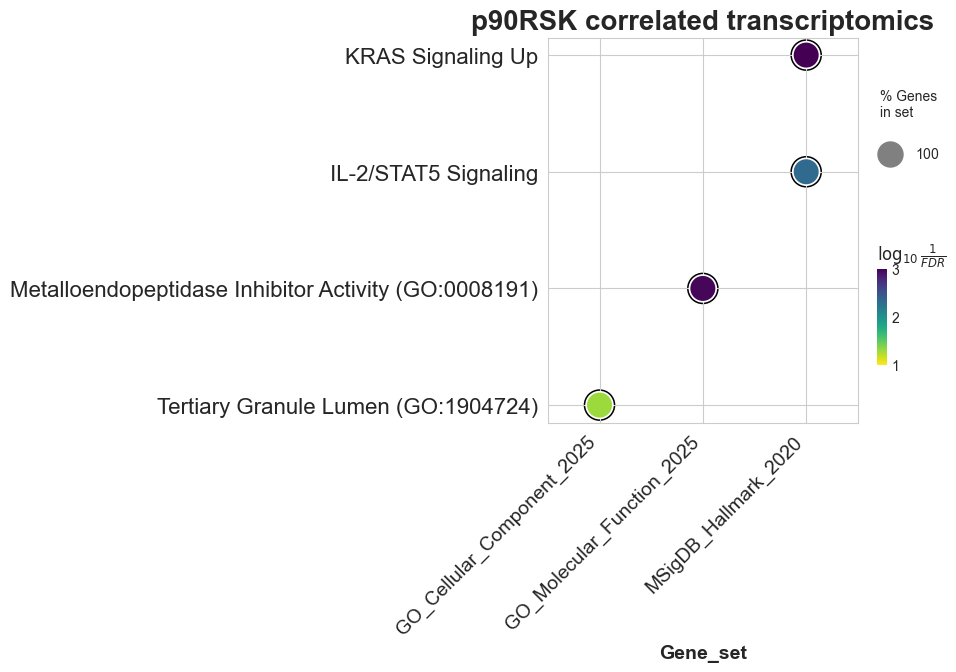

In [137]:
ax = gp.dotplot(
    enr_tx.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    top_term=5,
    figsize=(5,5),
    title = "p90RSK correlated transcriptomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.13/site-packages/gseapy/plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


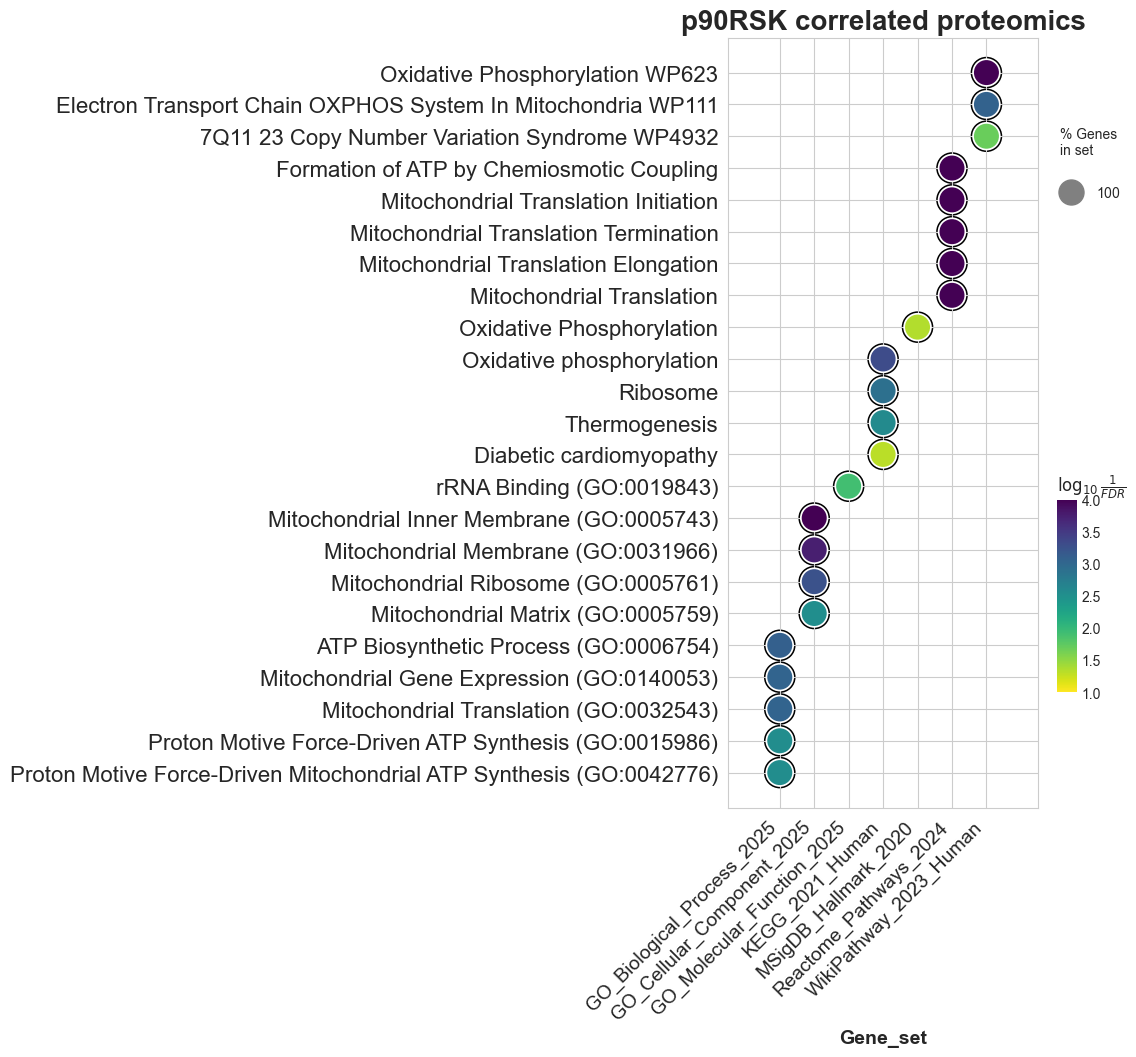

In [138]:
ax = gp.dotplot(
    enr_px.results,
    column="Adjusted P-value",
    x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
    size=3,
    top_term=5,
    figsize=(5,10),
    title = "p90RSK correlated proteomics",
    xticklabels_rot=45, # rotate xtick labels
    show_ring=True, # set to False to remove outer ring
    marker='o',
)